# Exploring `add_electricity.py` outputs

This jupyter notebook analyse the `add_electricity.py` **outputs**.

The `pypsa-earth/Snakefile` explicitly list in the **rule** what goes into the function `add_electricity.py` and what goes out (`elec.nc`). When inputs are commented out (#) than they are currently not considered. Maybe you want to make them run or develop new features? What can be observed from the inputs is that the script adds electrical generators, existing hydro storage, renewable generator profiles and loads units to a base network topology.

```
rule add_electricity:
    input:
        base_network='networks/base.nc',
        tech_costs=COSTS,
        regions="resources/regions_onshore.geojson",
        powerplants='resources/powerplants.csv',
        # hydro_capacities='data/bundle/hydro_capacities.csv',
        # geth_hydro_capacities='data/geth2015_hydro_capacities.csv',
        load='resources/ssp2-2.6/2030/era5_2013/Africa.nc',
        gadm_shapes='resources/gadm_shapes.geojson',
        **{f"profile_{tech}": f"resources/profile_{tech}.nc"
            for tech in config['renewable']}
    output: "networks/elec.nc"
    log: "logs/add_electricity.log"
    benchmark: "benchmarks/add_electricity"
    threads: 1
    resources: mem=3000
    script: "scripts/add_electricity.py"
```

Before analysing the outputs of add_electricity.py check that:
- `pypsa-earth` environment (/kernel) in jupyter notebook  is active and updated
- root folder where pypsa-earth is installed is named "pypsa-earth"
- or rename the below `sets_path_to_root("<folder_name>")` accordingly

In [1]:
# change current directory to parent folder
import os
import sys

if not os.path.isdir("pypsa-earth"):
    os.chdir("../..")
sys.path.append(os.getcwd()+"/pypsa-earth/scripts")

A jupyter notebook requires the user to import all they need. So we need to import all the required dependencies from the `pypsa-earth` environment:

In [2]:
import logging
import os

import pypsa
import yaml
import pandas as pd
import geopandas as gpd

# import geoviews as gv
# import hvplot.pandas
import numpy as np
import scipy as sp
import networkx as nx
import matplotlib as plt

from scipy.sparse import csgraph
from itertools import product

from shapely.geometry import Point, LineString
import shapely, shapely.prepared, shapely.wkt

logger = logging.getLogger(__name__)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 70)

## Network analysis

Now let's import the output file which should be in i.e. `~/pypsa-earth/networks/elec.nc`. 

Note: If you don't have the /elec.nc file yet in your folder structure, you could try to generate it from the terminal. In this case set the path so that you are located at `~/pypsa-earth`. Once you are there, use the command:
```
snakemake -j 1 networks/elec.nc
```
Note that this is something you can to for any other rule to generate it's outputs `snakemake -j 1 <output of rule>`

In [5]:
scenario_name = "KE_customPP"

scenario_subpath = scenario_name + "/" if scenario_name else ""

network_path = os.getcwd() + "/pypsa-earth/networks" + "/" + scenario_subpath + "elec.nc"

print(network_path)

n = pypsa.Network(network_path)
n
# print(n.links)
print(n.generators)


C:\Users\Marie\Semesterthesis\PyPSA-Earth-Project/pypsa-earth/networks/KE_customPP/elec.nc


Index(['transf_0_0', 'transf_2_0', 'transf_4_0', 'transf_5_0', 'transf_6_0',
       'transf_7_0', 'transf_8_0', 'transf_10_0', 'transf_10_1', 'transf_12_0',
       'transf_15_0', 'transf_15_1', 'transf_16_0', 'transf_17_0',
       'transf_18_0', 'transf_22_0', 'transf_22_1', 'transf_24_0',
       'transf_26_0', 'transf_27_0', 'transf_32_0', 'transf_34_0',
       'transf_69_0'],
      dtype='object', name='name')
Index(['transf_0_0', 'transf_2_0', 'transf_4_0', 'transf_5_0', 'transf_6_0',
       'transf_7_0', 'transf_8_0', 'transf_10_0', 'transf_10_1', 'transf_12_0',
       'transf_15_0', 'transf_15_1', 'transf_16_0', 'transf_17_0',
       'transf_18_0', 'transf_22_0', 'transf_22_1', 'transf_24_0',
       'transf_26_0', 'transf_27_0', 'transf_32_0', 'transf_34_0',
       'transf_69_0'],
      dtype='object', name='name')
Index(['transf_0_0', 'transf_2_0', 'transf_4_0', 'transf_5_0', 'transf_6_0',
       'transf_7_0', 'transf_8_0', 'transf_10_0', 'transf_10_1', 'transf_12_0',
       'tra

                                carrier  bus  p_nom_min  p_nom  \
Generator                                                        
CAkiira Geothermal           geothermal   10       70.0   70.0   
CAthi River Gulf                    oil   65       80.0   80.0   
CBaringo GDC Project Korosi  geothermal  103      100.0  100.0   
CBaringo GDC Project Paka    geothermal  103      100.0  100.0   
CBaringo GDC Project Silali  geothermal  103      100.0  100.0   
...                                 ...  ...        ...    ...   
16 hydro                            ror   58        0.0   20.0   
17 hydro                            ror    5        0.0  106.0   
18 hydro                            ror    6        0.0    7.4   
19 hydro                            ror   85        0.0  200.0   
20 hydro                            ror   85        0.0  200.0   

                             p_nom_extendable  efficiency  marginal_cost  \
Generator                                                        

You might be interested to see what's in the Network Common Data Form or NetCDF (.nc) file. To assess that we use **xarray**

In [6]:
import xarray as xr

path = network_path
network_data = xr.open_dataset(path)

network_data

<xarray.Dataset> Size: 30MB
Dimensions:                       (snapshots: 8760, investment_periods: 0,
                                   lines_i: 92, loads_i: 81,
                                   loads_t_p_set_i: 81, generators_i: 223,
                                   generators_t_p_max_pu_i: 187, buses_i: 105,
                                   carriers_i: 15, links_i: 1,
                                   transformers_i: 23)
Coordinates:
  * snapshots                     (snapshots) int64 70kB 0 1 2 ... 8758 8759
  * investment_periods            (investment_periods) int64 0B 
  * lines_i                       (lines_i) <U2 736B '0' '1' '2' ... '86' '87'
  * loads_i                       (loads_i) <U3 972B '0' '2' '3' ... '103' '104'
  * loads_t_p_set_i               (loads_t_p_set_i) <U3 972B '0' '2' ... '104'
  * generators_i                  (generators_i) <U39 35kB 'CAkiira Geotherma...
  * generators_t_p_max_pu_i       (generators_t_p_max_pu_i) <U13 10kB '0 onwi...
  * buses_i                       (buses_i) <U3 1kB '0' '1' '2' ... '103' '104'
  * carriers_i                    (carriers_i) <U10 600B 'lignite' ... 'ror'
  * links_i                       (links_i) <U13 52B 'convert_26_46'
  * transformers_i                (transformers_i) <U11 1kB 'transf_0_0' ... ...
Data variables: (12/84)
    snapshots_snapshot            (snapshots) datetime64[ns] 70kB ...
    snapshots_objective           (snapshots) float64 70kB ...
    snapshots_generators          (snapshots) float64 70kB ...
    snapshots_stores              (snapshots) float64 70kB ...
    investment_periods_objective  (investment_periods) float64 0B ...
    investment_periods_years      (investment_periods) float64 0B ...
    ...                            ...
    transformers_bus0_lon         (transformers_i) float64 184B ...
    transformers_bus0_lat         (transformers_i) float64 184B ...
    transformers_bus1_lon         (transformers_i) float64 184B ...
    transformers_bus1_lat         (transformers_i) float64 184B ...
    transformers_x                (transformers_i) float64 184B ...
    transformers_s_nom            (transformers_i) float64 184B ...
Attributes:
    network_name:           PyPSA-Earth
    network_pypsa_version:  0.30.3
    network_srid:           4326
    crs:                    {"_crs": "GEOGCRS[\"WGS 84\",ENSEMBLE[\"World Geo...
    meta:                   {"version": "0.6.0", "tutorial": false, "logging"...

A quick check of the network topology:

C:\Users\Marie\anaconda3\envs\pypsa-earth\Lib\site-packages\cartopy\mpl\feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


(<matplotlib.collections.PatchCollection at 0x13a2054ba90>,
 <matplotlib.collections.LineCollection at 0x13a1c12ae90>)

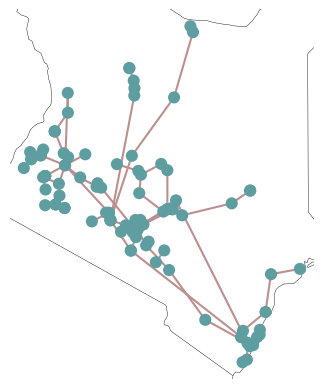

In [7]:
n.plot()

A full list of components are given: https://pypsa.readthedocs.io/en/latest/components.html#
We always check the PyPSA documentation to find analyse the components of interest.

In [8]:
#n.buses.head(4)

n.buses[n.buses["control"] == "PQ"].head(4)

,v_nom,symbol,under_construction,tag_substation,tag_area,lon,lat,country,substation_lv,carrier,x,y,substation_off,type,unit,v_mag_pu_set,v_mag_pu_min,v_mag_pu_max,control,generator,sub_network
Bus,,,,,,,,,,,,,,,,,,,,,
0,132.0,substation,False,transmission,0.0,36.9150,-1.2589,KE,True,AC,36.9150,-1.2589,True,,,1.0,0.0,inf,PQ,,
1,220.0,substation,False,transmission,0.0,36.9160,-1.2579,KE,False,AC,36.9160,-1.2579,True,,,1.0,0.0,inf,PQ,,
2,132.0,substation,False,transmission,0.0,35.2630,0.5008,KE,True,AC,35.2630,0.5008,True,,,1.0,0.0,inf,PQ,,
3,132.0,substation,False,transmission,0.0,37.6867,-0.8067,KE,True,AC,37.6867,-0.8067,True,,,1.0,0.0,inf,PQ,,


In [14]:
n.lines.head(2)

,num_parallel,v_nom,bus0,bus1,length,dc,geometry,bounds,carrier,type,s_max_pu,s_nom,underwater_fraction,capital_cost,x,r,g,b,s_nom_mod,s_nom_extendable,s_nom_min,s_nom_max,build_year,lifetime,terrain_factor,v_ang_min,v_ang_max,sub_network,x_pu,r_pu,g_pu,b_pu,x_pu_eff,r_pu_eff,s_nom_opt
Line,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,3.0,132.0,40,20,NaN,False,"LINESTRING (37.0288 -0.4314, 37.028665199999985 -0.4307265, 37.027...","MULTIPOINT ((37.0288 -0.4314), (37.068 -0.0016))",AC,243-AL1/39-ST1A 20.0,0.7,442.400417,0.0,NaN,0.0,0.0,0.0,0.0,0.0,False,0.0,inf,0,inf,1.0,-inf,inf,,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,3.0,220.0,42,1,NaN,False,"LINESTRING (36.9908 -1.2825, 36.976124 -1.2657485, 36.974339 -1.26...","MULTIPOINT ((36.9908 -1.2825), (36.916 -1.2579))",AC,Al/St 240/40 2-bundle 220.0,0.7,1474.668058,0.0,NaN,0.0,0.0,0.0,0.0,0.0,False,0.0,inf,0,inf,1.0,-inf,inf,,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [20]:
# output of generators
# n.generators.head(10)
print(n.generators[n.generators["carrier"]=="solar"])

          carrier  bus  p_nom_min      p_nom  p_nom_extendable  efficiency  \
Generator                                                                    
0 solar     solar    0   0.106373   0.106373              True         1.0   
2 solar     solar    2   1.606136   1.606136              True         1.0   
3 solar     solar    3   0.521003   0.521003              True         1.0   
5 solar     solar    5  30.155565  30.155565              True         1.0   
6 solar     solar    6   0.773858   0.773858              True         1.0   
...           ...  ...        ...        ...               ...         ...   
100 solar   solar  100   2.635528   2.635528              True         1.0   
101 solar   solar  101   7.198493   7.198493              True         1.0   
102 solar   solar  102   5.241590   5.241590              True         1.0   
103 solar   solar  103   3.142451   3.142451              True         1.0   
104 solar   solar  104   3.745055   3.745055              True  

In [21]:
# nominal power output grouped by carrier
n.generators.groupby("carrier").p_nom.sum() # in 2030 Kenya has already more installed solar capacity.

# The maximal available power output
#n.generators.groupby("carrier").p_nom_max.sum() / 1e3  # converted in [GW], p_nom_max not defined


carrier
CCGT           277.000000
biomass         12.000000
geothermal    1525.500000
nuclear       1000.000000
offwind-ac       0.000000
offwind-dc       0.000000
oil            421.500000
onwind         434.811645
solar          357.543428
Name: p_nom, dtype: float64

In [17]:
# The (by the model) optimised installed power
n.generators.groupby("carrier").p_nom_opt.sum() / 1000  # converted in [GW], p_nom_opt currently = 0

carrier
CCGT          0.0
biomass       0.0
geothermal    0.0
nuclear       0.0
offwind-ac    0.0
offwind-dc    0.0
oil           0.0
onwind        0.0
solar         0.0
Name: p_nom_opt, dtype: float64

### Maximal available wind profile (as p.u.)

A time series is of the type of "series". See: https://pypsa.readthedocs.io/en/latest/components.html#generator
This requires to use `n.generator_t.p_max_pu` instead `n.generator.p_max_pu`

In [18]:
# n.generators_t.p_max_pu

# output for the first day (0 to 24 h) and generator in column 10
# n.generators_t.p_max_pu.iloc[0:24,10].plot()

# n.generators_t.p_max_pu.iloc[[, 0].plot()
# n.generators_t.p_max_pu.iloc[:, 0].plot()

# Load timeseries


<AxesSubplot:xlabel='snapshot'>

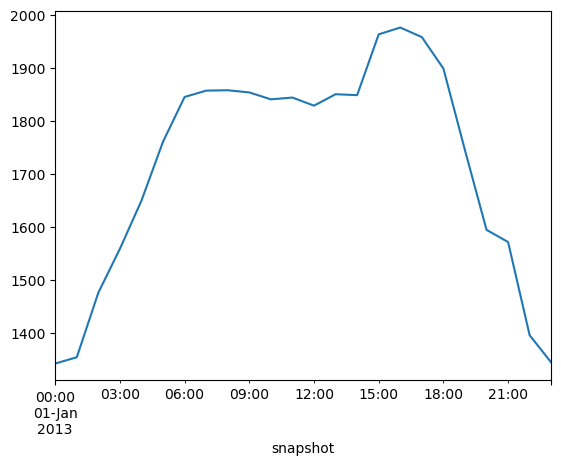

In [19]:
# load time series for one day (1.1.13), plot over sum of all the loads, not individual generators
n.loads_t.p_set.sum(axis=1).iloc[0:24].plot()

# load time series for all year
# n.loads_t.p_set.sum(axis=1).plot()